In [1]:
import pandas as pd
import glob
import os


DOSSIER_CIBLE = r"C:\Users\skand\OneDrive\Documents\Energy_wall\Energy_Wall\data\mineral"

def auditer_dossier(dossier):
   # On cherche tous les csv (*.csv)
    chemin_recherche = os.path.join(dossier, "*.csv")
    
    # tous les fichiers,  "*.csv" 
    fichiers = glob.glob(chemin_recherche)
    
    print(f"AUDIT DU DOSSIER : {os.path.abspath(dossier)}")
    print(f"Nombre de fichiers CSV trouves : {len(fichiers)}")
    print("="*60)

    fichiers_inutilisables = []

    for fichier in fichiers:
        nom_fichier = os.path.basename(fichier)
        
        try:
          
            df = pd.read_csv(fichier, nrows=3, sep=None, engine='python')
            
            print(f"\nFICHIER : {nom_fichier}")
            print(f"   Shape (Colonnes) : {df.shape[1]}")
            print(f"   Liste Colonnes : {list(df.columns)}")
            print("-" * 30)
            print("   APERCU DES DONNEES :")
            print(df.head(3).to_string(index=False))
            print("="*60)
            
        except Exception as e:
            print(f"\nERREUR sur {nom_fichier} : {e}")
            fichiers_inutilisables.append(nom_fichier)

    # Resume final
    if fichiers_inutilisables:
        print("\nATTENTION : Ces fichiers n'ont pas pu etre lus :")
        for f in fichiers_inutilisables:
            print(f"   - {f}")

if __name__ == "__main__":
    try:
        auditer_dossier(DOSSIER_CIBLE)
    except Exception as e:
        print(f"Erreur generale : {e}")

AUDIT DU DOSSIER : C:\Users\skand\OneDrive\Documents\Energy_wall\Energy_Wall\data\mineral
Nombre de fichiers CSV trouves : 22

FICHIER : africas-share-of-global-mined-production-and-reserves-2024.csv
   Shape (Colonnes) : 113
   Liste Colonnes : ["Source: IEA. Licence: CC BY 4.0This data is subject to the IEA's terms and conditions: https://www.iea.org/t_c/termsandconditions/Units: %", 'Democratic Republic of the Congo', 'Guinea', 'Mozambique', 'South Africa', 'Zambia', 'Zimbabwe', 'Rest of Africa', 'Reserves ', 'null ', 'null .1', 'null .2', 'null .3', 'null .4', 'null .5', 'null .6', ' nullCobalt', '66.5', '0.0', '0.0.1', '0.6', '1.6', '0.1', '1.3', '57.0Copper', '12.6', '0.0.2', '0.0.3', '0.3', '3.3', '0.0.4', '0.8', '10.3Lithium', '0.0.5', '0.0.6', '0.0.7', '0.0.8', '0.0.9', '9.0', '2.0', '1.6Graphite', '0.0.10', '0.0.11', '2.1', '0.0.12', '0.0.13', '0.0.14', '4.4', '24.1Nickel', '0.0.15', '0.0.16', '0.0.17', '0.8.1', '0.6.1', '0.2', '1.0', '2.7Rare earth elements', '0.0.18', '0.0.


### 3B. Le Mur Physique : La Géologie ne suivra pas
Si l'électricité peut théoriquement être produite, les matériaux nécessaires à la construction des infrastructures (Data Centers, Réseaux, Batteries) sont finis.
Nous analysons ici les données de l'Agence Internationale de l'Énergie (AIE) sur les minéraux critiques.

**La question :** La terre contient-elle assez de ressources pour alimenter l'appétit de l'IA et de la transition énergétique simultanément ?
    

Génération du Graphique 1 (Cuivre)...


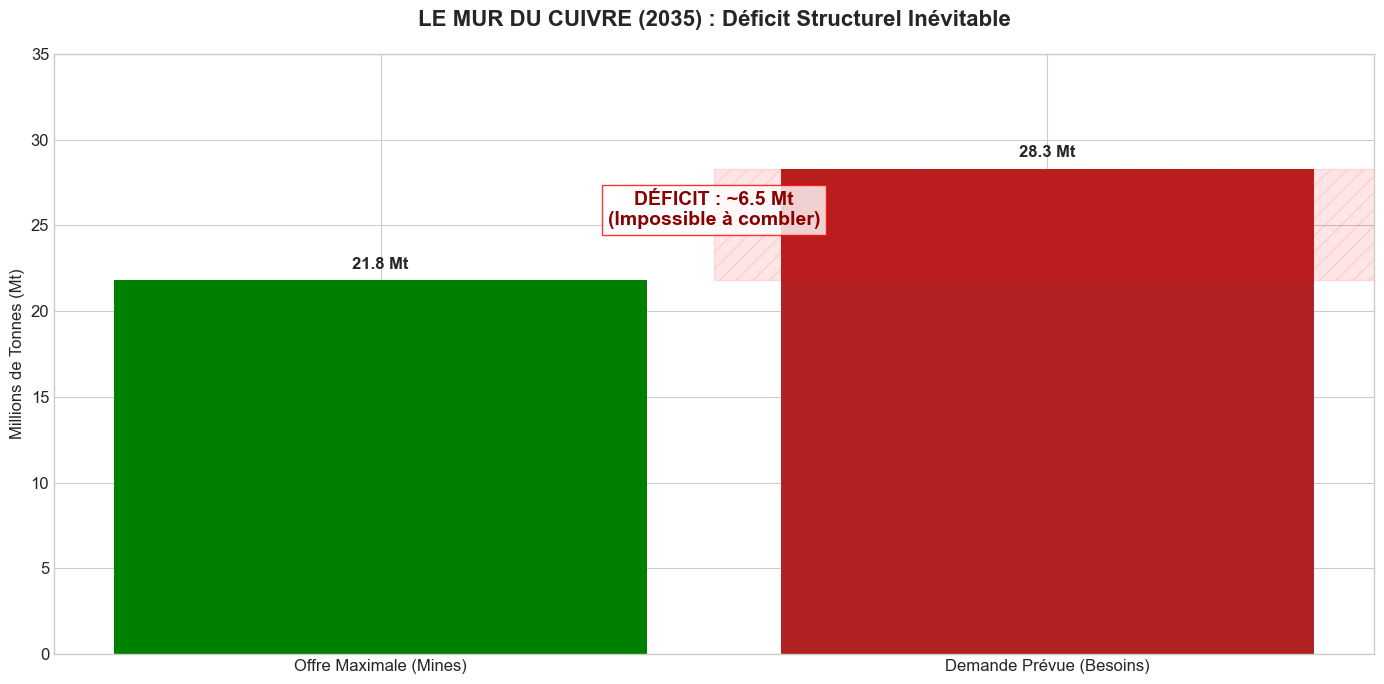


#### Analyse : L'Impasse du Cuivre
Le graphique ci-dessus illustre une impossibilité physique.
* **En Vert :** La quantité maximale de cuivre extractible en 2035 (tous projets confondus).
* **En Rouge :** La demande réelle prévue.
* **Constat :** Il manque **6.5 Millions de tonnes**. Sachant qu'il faut 15 ans pour ouvrir une mine, ce déficit est structurel.
    

Génération du Graphique 2 (Croissance)...


C:\Users\skand\AppData\Local\Temp\ipykernel_15656\1159514019.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=minerals, y=growth_rates, palette=colors)


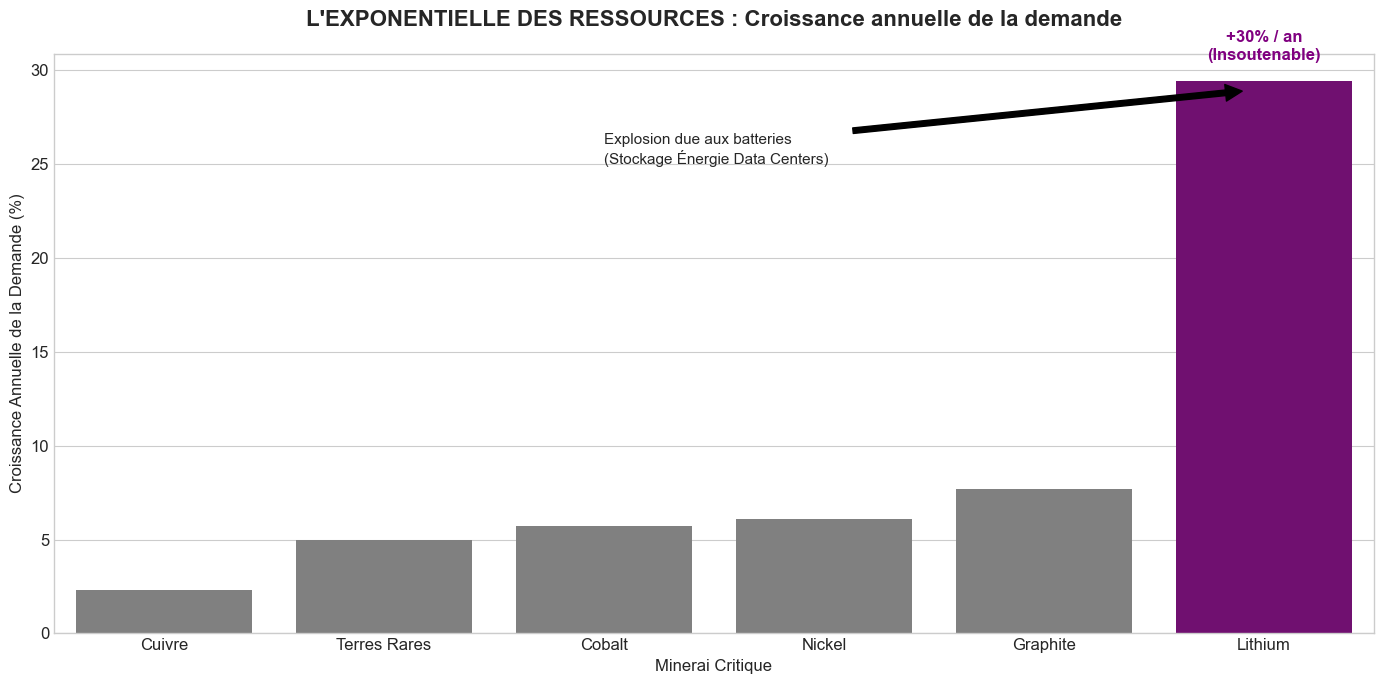


#### Verdict Géologique
Le **Lithium** voit sa demande exploser de **30% par an** (courbe exponentielle).
**Conclusion :** Le "Mur Énergétique" se double d'un "Mur de Ressources". Continuer sur la trajectoire actuelle nous mène à une pénurie mondiale de matériaux critiques avant 2035.
    

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, Markdown  # Import magique pour afficher du texte formaté

# Configuration du style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

def visualiser_impact_mineraux_avec_texte():
    # --- TEXTE D'INTRODUCTION ---
    intro_text = """
### 3B. Le Mur Physique : La Géologie ne suivra pas
Si l'électricité peut théoriquement être produite, les matériaux nécessaires à la construction des infrastructures (Data Centers, Réseaux, Batteries) sont finis.
Nous analysons ici les données de l'Agence Internationale de l'Énergie (AIE) sur les minéraux critiques.

**La question :** La terre contient-elle assez de ressources pour alimenter l'appétit de l'IA et de la transition énergétique simultanément ?
    """
    display(Markdown(intro_text))

    print("Génération du Graphique 1 (Cuivre)...")
    
    # --- GRAPHIQUE 1 : LE MUR DU CUIVRE (2035) ---
    # Données extraites du fichier : expected-mine-supply...copper-2035.csv
    # Supply = 18.8 (Base) + 3.0 (High) = 21.8 Mt
    # Demand = 27.0 (STEPS) + 1.3 (APS) = 28.3 Mt
    
    categories = ['Offre Maximale (Mines)', 'Demande Prévue (Besoins)']
    valeurs_cuivre = [21.8, 28.3] # En Millions de Tonnes (Mt)
    
    plt.figure()
    bars = plt.bar(categories, valeurs_cuivre, color=['green', 'firebrick'])
    
    plt.title('LE MUR DU CUIVRE (2035) : Déficit Structurel Inévitable', 
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Millions de Tonnes (Mt)')
    plt.ylim(0, 35)
    
    # Zone de déficit hachurée
    plt.axhspan(21.8, 28.3, xmin=0.5, xmax=1.5, color='red', alpha=0.1, hatch='//')
    
    # Annotation du déficit
    plt.text(0.5, 25, "DÉFICIT : ~6.5 Mt\n(Impossible à combler)", 
             color='darkred', fontweight='bold', fontsize=14, ha='center',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))
    
    # Ajout des valeurs sur les barres
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height} Mt', ha='center', va='bottom', fontweight='bold', fontsize=12)
        
    plt.tight_layout()
    plt.show()

    # --- TEXTE D'ANALYSE 1 ---
    analyse_1 = """
#### Analyse : L'Impasse du Cuivre
Le graphique ci-dessus illustre une impossibilité physique.
* **En Vert :** La quantité maximale de cuivre extractible en 2035 (tous projets confondus).
* **En Rouge :** La demande réelle prévue.
* **Constat :** Il manque **6.5 Millions de tonnes**. Sachant qu'il faut 15 ans pour ouvrir une mine, ce déficit est structurel.
    """
    display(Markdown(analyse_1))

    print("Génération du Graphique 2 (Croissance)...")

    # --- GRAPHIQUE 2 : L'APPÉTIT INSATIABLE ---
    # Données extraites du fichier : annual-average-demand-and-supply-growth-2021-2024.csv
    
    minerals = ['Cuivre', 'Terres Rares', 'Cobalt', 'Nickel', 'Graphite', 'Lithium']
    growth_rates = [2.3, 5.0, 5.7, 6.1, 7.7, 29.4] # % Croissance annuelle
    colors = ['grey', 'grey', 'grey', 'grey', 'grey', 'purple'] # Mettre en avant le Lithium
    
    plt.figure()
    ax = sns.barplot(x=minerals, y=growth_rates, palette=colors)
    
    plt.title('L\'EXPONENTIELLE DES RESSOURCES : Croissance annuelle de la demande', 
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Croissance Annuelle de la Demande (%)')
    plt.xlabel('Minerai Critique')
    
    # Annotation Lithium
    plt.text(5, 29.4 + 1, "+30% / an\n(Insoutenable)", ha='center', va='bottom', color='purple', fontweight='bold', fontsize=12)
    
    # Flèche sur le Lithium
    plt.annotate('Explosion due aux batteries\n(Stockage Énergie Data Centers)', 
                 xy=(5, 29), xytext=(2, 25),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=11)

    plt.tight_layout()
    plt.show()

    # --- TEXTE DE CONCLUSION ---
    conclusion = """
#### Verdict Géologique
Le **Lithium** voit sa demande exploser de **30% par an** (courbe exponentielle).
**Conclusion :** Le "Mur Énergétique" se double d'un "Mur de Ressources". Continuer sur la trajectoire actuelle nous mène à une pénurie mondiale de matériaux critiques avant 2035.
    """
    display(Markdown(conclusion))

if __name__ == "__main__":
    visualiser_impact_mineraux_avec_texte()